## Paso 1: Cargar el Dataset

Dado que tienes el dataset en tu ordenador, el primer paso es subirlo a tu entorno de Colab. Puedes hacerlo arrastrando y soltando el archivo en el panel de archivos de la izquierda, o usando el siguiente código para subirlo programáticamente.

In [1]:
import zipfile
import os

# Como el Google Drive está sincronizado localmente (unidad G:), los archivos
# ya están disponibles en el sistema de archivos: no hace falta "subirlos".
zip_files = ['DEAM_audio.zip', 'DEAM_Annotations.zip', 'DEAM_Features.zip']

## Paso 2: Montar Drive y usar las carpetas ya extraídas

Este notebook corre en Colab hosted (una VM en la nube de Google), así que la unidad `G:` de tu PC **no existe** ahí — solo existe en tu máquina local. Montamos Drive con `drive.mount()` y nos movemos a la carpeta de este proyecto dentro de Drive, donde `DEAM_audio`, `DEAM_Annotations` y `DEAM_Features` ya están descomprimidas de una sesión anterior — así el resto del notebook las usa por ruta relativa sin re-extraer nada.

In [2]:
import zipfile
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

# Nos movemos a la carpeta de este proyecto dentro de Drive: aquí ya están
# extraídas DEAM_audio/DEAM_Annotations/DEAM_Features de una sesión previa,
# así que el resto del notebook las usa por ruta relativa sin volver a
# descomprimir los .zip (pesan varios GB y tardan minutos).
project_dir = '/content/drive/MyDrive/Colab Notebooks/[Data]/[Trained Models]/musicAnalyzer(CNN)'
os.chdir(project_dir)
print(f"Directorio de trabajo: {os.getcwd()}")

base_path = '/content/drive/MyDrive/Colab Notebooks/[Data]'
zip_files = ['DEAM_audio.zip', 'DEAM_Annotations.zip', 'DEAM_Features.zip']

for zip_file in zip_files:
    zip_path = os.path.join(base_path, zip_file)
    extract_folder = zip_file.replace('.zip', '')

    # Si la carpeta ya existe con contenido (extracción de una sesión previa),
    # la reutilizamos directamente: los .zip pesan varios GB y tardan minutos.
    if os.path.isdir(extract_folder) and os.listdir(extract_folder):
        print(f'Ya existe {extract_folder} con contenido, se usa directamente (sin re-extraer).')
        continue

    if os.path.exists(zip_path):
        print(f'Extrayendo {zip_path}...')
        os.makedirs(extract_folder, exist_ok=True)
        try:
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_folder)
            print(f'¡Éxito! Contenido extraído en el directorio: {extract_folder}')
        except zipfile.BadZipFile:
            file_size = os.path.getsize(zip_path)
            print(f'Error: {zip_path} no es un archivo ZIP válido. Está corrupto o incompleto.')
            print(f'Tamaño actual: {file_size} bytes. Por favor, verifica el archivo en tu Drive.')
        except Exception as e:
            print(f'Ocurrió un error al extraer {zip_file}: {e}')
    else:
        print(f'Advertencia: No se encontró {zip_path}. Asegúrate de que el archivo esté en la ruta especificada en Google Drive.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio de trabajo: /content/drive/MyDrive/Colab Notebooks/[Data]/[Trained Models]/musicAnalyzer(CNN)
Ya existe DEAM_audio con contenido, se usa directamente (sin re-extraer).
Ya existe DEAM_Annotations con contenido, se usa directamente (sin re-extraer).
Ya existe DEAM_Features con contenido, se usa directamente (sin re-extraer).


## Paso 3: Cargar Anotaciones y Preparar LabelEncoder

Necesitamos cargar las anotaciones de las emociones para cada canción y preparar un `LabelEncoder` para convertir las etiquetas de texto (Alegre, Neutra, Triste) a valores numéricos, que es lo que el modelo de machine learning espera.

In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import os

# Filtrar específicamente los archivos que contienen las anotaciones ya promediadas por canción
annotations_dir = 'DEAM_Annotations'
csv_files = []

for root, dirs, files in os.walk(annotations_dir):
    for file in files:
        # Buscamos solo en la carpeta de valores promediados por canción (averaged per song)
        if file.endswith('.csv') and 'averaged_songs' in file.lower() and 'averaged' in root.lower():
            csv_files.append(os.path.join(root, file))

if not csv_files:
    # Fallback en caso de que la estructura cambie ligeramente
    for root, dirs, files in os.walk(annotations_dir):
        for file in files:
            if file.endswith('.csv') and 'averaged' in file.lower():
                csv_files.append(os.path.join(root, file))

print(f"Archivos de anotaciones promedio encontrados: {csv_files}")

# Cargar y concatenar únicamente los archivos promedio
df_list = []
for file_path in csv_files:
    df_temp = pd.read_csv(file_path)
    df_temp.columns = df_temp.columns.str.strip()
    df_list.append(df_temp)

df_annotations = pd.concat(df_list, ignore_index=True)
print(f"Total de canciones únicas cargadas: {len(df_annotations)}")

# Obtener nombres de columnas correctas
arousal_name = [col for col in df_annotations.columns if 'arousal' in col.lower() and 'mean' in col.lower()][0]
valence_name = [col for col in df_annotations.columns if 'valence' in col.lower() and 'mean' in col.lower()][0]
song_id_name = [col for col in df_annotations.columns if 'song_id' in col.lower() or 'id' in col.lower()][0]

df_avg = df_annotations[[song_id_name, arousal_name, valence_name]].copy()
df_avg.rename(columns={song_id_name: 'song_id', arousal_name: 'Arousal', valence_name: 'Valence'}, inplace=True)

# Limpiar filas con valores nulos si existieran
df_avg.dropna(subset=['Arousal', 'Valence'], inplace=True)

# En DEAM, la escala es de 1 a 9. Usamos 5 como punto medio para la clasificación
def classify_emotion(row):
    if row['Arousal'] > 5 and row['Valence'] > 5:
        return 'Alegre'
    elif row['Arousal'] <= 5 and row['Valence'] <= 5:
        return 'Triste'
    else:
        return 'Neutra'

df_avg['Emocion'] = df_avg.apply(classify_emotion, axis=1)

# Inicializar y ajustar el codificador de etiquetas
le = LabelEncoder()
df_avg['emotion_encoded'] = le.fit_transform(df_avg['Emocion'])

print("\ndf_avg (primeras 5 filas limpias):")
display(df_avg.head())
print(f"Distribución de clases:\n{df_avg['Emocion'].value_counts()}")
print("\n¡LabelEncoder (le) y df_avg están listos de forma correcta y sin valores nulos!")

Archivos de anotaciones promedio encontrados: ['DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_2000_2058.csv', 'DEAM_Annotations/annotations/annotations averaged per song/song_level/static_annotations_averaged_songs_1_2000.csv']
Total de canciones únicas cargadas: 1802

df_avg (primeras 5 filas limpias):


,song_id,Arousal,Valence,Emocion,emotion_encoded
0,2001,6.6,3.2,Neutra,1
1,2002,5.2,6.4,Alegre,0
2,2003,4.6,5.4,Neutra,1
3,2004,4.8,5.0,Triste,2
4,2005,5.2,3.8,Neutra,1


Distribución de clases:
Emocion
Triste    742
Alegre    594
Neutra    466
Name: count, dtype: int64

¡LabelEncoder (le) y df_avg están listos de forma correcta y sin valores nulos!


## Paso 4: Implementación de CNN + LSTM

Para aprovechar la arquitectura CNN+LSTM, necesitamos modificar cómo extraemos las características. En lugar de calcular una única media o desviación estándar por canción, necesitamos una secuencia de características para cada pequeño segmento de tiempo (o 'frame') del audio. Luego, esta secuencia será la entrada para nuestra red neuronal.

### Extracción de Características a Nivel de Frame (desde el audio crudo, mismo call que la inferencia)


In [4]:
pip install opensmile

In [5]:
import pandas as pd
import numpy as np
import opensmile
from tqdm.notebook import tqdm
import os

# Verificar el LabelEncoder
if 'le' not in locals():
    raise NameError("El LabelEncoder (le) no está definido. Por favor, ejecuta el Paso 7 (celda 2f88856d).")

max_sequence_length = 0
all_sequences = []
all_labels = []

# Extraemos las características directamente del AUDIO CRUDO de DEAM, con la MISMA
# llamada de openSMILE que usa la inferencia real (antes se cargaban los CSVs
# pre-extraídos de DEAM_Features, con un config desconocido y distinto al de
# inferencia -> desajuste de dominio: 260 columnas "reales" en entrenamiento vs 65
# columnas reales + 195 de relleno con ceros en inferencia).
audio_dir = 'DEAM_audio/MEMD_audio'
cache_dir = os.path.join(base_path, 'DEAM_LLD_cache')
os.makedirs(cache_dir, exist_ok=True)

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
)

print("Extrayendo características LLD (ComParE_2016) desde el audio crudo de DEAM...")
print(f"Caché en Drive: {cache_dir} (persiste entre sesiones de Colab, evita re-extraer si se corta la sesión)")

# Aseguremonos de que df_avg esté ordenado y limpio
df_avg_sorted = df_avg.sort_values(by='song_id').reset_index(drop=True)

for idx, row in tqdm(df_avg_sorted.iterrows(), total=len(df_avg_sorted), desc="Extrayendo características"):
    song_id = int(row['song_id'])
    emotion = row['Emocion']

    cache_path = os.path.join(cache_dir, f'{song_id}.npy')

    try:
        if os.path.exists(cache_path):
            sequence = np.load(cache_path)
        else:
            audio_path = os.path.join(audio_dir, f'{song_id}.mp3')
            if not os.path.exists(audio_path):
                continue
            feats = smile.process_file(audio_path)
            sequence = feats.select_dtypes(include=[np.number]).values.astype('float32')
            np.save(cache_path, sequence)

        if sequence.shape[1] > 0:
            all_sequences.append(sequence)
            all_labels.append(le.transform([emotion])[0])

            # Guardar la longitud de secuencia más larga
            if sequence.shape[0] > max_sequence_length:
                max_sequence_length = sequence.shape[0]

    except Exception as e:
        continue

print(f"\nCaracterísticas temporales cargadas correctamente para {len(all_sequences)} canciones.")
print(f"Longitud máxima de secuencia encontrada: {max_sequence_length} frames.")
print(f"Número de características por frame: {all_sequences[0].shape[1] if all_sequences else 0}")

# Convertir a variables finales para el preprocesamiento
X_cnn_lstm = all_sequences
y_cnn_lstm = np.array(all_labels)


Extrayendo características LLD (ComParE_2016) desde el audio crudo de DEAM...
Caché en Drive: /content/drive/MyDrive/Colab Notebooks/[Data]/DEAM_LLD_cache (persiste entre sesiones de Colab, evita re-extraer si se corta la sesión)


Extrayendo características:   0%|          | 0/1802 [00:00<?, ?it/s]


Características temporales cargadas correctamente para 1802 canciones.
Longitud máxima de secuencia encontrada: 62713 frames.
Número de características por frame: 65


## Paso 4.1 Preprocesamiento de Datos (Padding y Split)

In [6]:
import tensorflow as tf
import keras
# Importación segura de pad_sequences para evitar conflictos entre versiones de Keras/TensorFlow
try:
    from keras.utils import pad_sequences
except ImportError:
    from keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
import numpy as np

# Asegurar que las secuencias están cargadas en el entorno actual
if 'X_cnn_lstm' not in locals() or not X_cnn_lstm:
    raise ValueError("No se encontraron secuencias de características en 'X_cnn_lstm'. Por favor, asegúrate de volver a ejecutar la celda anterior (f6aa799c) para cargar los datos en memoria antes de esta celda.")

num_features_per_frame = X_cnn_lstm[0].shape[1]

lengths = np.array([seq.shape[0] for seq in X_cnn_lstm])
print(f"Longitud de secuencia — min: {lengths.min()}, mediana: {int(np.median(lengths))}, "
      f"p95: {int(np.percentile(lengths, 95))}, máxima: {lengths.max()} frames.")

# Usar la longitud máxima real (p.ej. 62713 frames) dispararía un array de
# ~1800 * 62713 * 65 * 4 bytes ≈ 29 GB, que revienta la RAM y mata el kernel.
# Usamos el percentil 95 como tope: cubre casi todas las canciones y trunca
# solo los outliers muy largos, mantiendo el tamaño del array en un rango
# manejable.
max_seq_len = int(np.percentile(lengths, 95))
print(f"Número de características por frame: {num_features_per_frame}")
print(f"Realizando padding/truncado a {max_seq_len} frames (percentil 95, en vez del máximo absoluto)...")

estimated_gb = len(X_cnn_lstm) * max_seq_len * num_features_per_frame * 4 / (1024 ** 3)
print(f"Tamaño estimado de X_padded: ~{estimated_gb:.2f} GB")

# Rellenar/truncar secuencias para que todas tengan la misma longitud
X_padded = pad_sequences(X_cnn_lstm, maxlen=max_seq_len, dtype='float32', padding='post', truncating='post', value=0.0)

print(f"Forma final de los datos transformados (X_padded): {X_padded.shape}")

# Dividir los datos en conjuntos de entrenamiento y prueba usando estratificación
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_padded, y_cnn_lstm, test_size=0.2, random_state=42, stratify=y_cnn_lstm
)

print(f"\nTamaño de X_train para CNN+LSTM: {X_train_cnn.shape}")
print(f"Tamaño de X_test para CNN+LSTM: {X_test_cnn.shape}")
print(f"Tamaño de y_train para CNN+LSTM: {y_train_cnn.shape}")
print(f"Tamaño de y_test para CNN+LSTM: {y_test_cnn.shape}")

Longitud de secuencia — min: 4460, mediana: 4499, p95: 4504, máxima: 62713 frames.
Número de características por frame: 65
Realizando padding/truncado a 4504 frames (percentil 95, en vez del máximo absoluto)...
Tamaño estimado de X_padded: ~1.97 GB
Forma final de los datos transformados (X_padded): (1802, 4504, 65)

Tamaño de X_train para CNN+LSTM: (1441, 4504, 65)
Tamaño de X_test para CNN+LSTM: (361, 4504, 65)
Tamaño de y_train para CNN+LSTM: (1441,)
Tamaño de y_test para CNN+LSTM: (361,)


## Paso 4.2 Balanceo del Conjunto de Entrenamiento

Para evitar que nuestro modelo se sesgue hacia la clase mayoritaria, aplicaremos un submuestreo en el conjunto de entrenamiento de manera que todas las emociones tengan el mismo número de muestras (igualando a la clase minoritaria).

In [9]:
import numpy as np
from collections import Counter

# Analizar la distribución original en el entrenamiento
print("Distribución original de y_train_cnn:", Counter(y_train_cnn))

# Encontrar el tamaño de la clase minoritaria
class_counts = Counter(y_train_cnn)
min_class_size = min(class_counts.values())
print(f"Tamaño de la clase minoritaria en entrenamiento: {min_class_size}")

# Realizar el submuestreo de manera aleatoria por clase
balanced_indices = []

for emotion_class in class_counts.keys():
    # Obtener índices pertenecientes a la clase actual
    indices = np.where(y_train_cnn == emotion_class)[0]
    # Seleccionar aleatoriamente un número de índices igual a min_class_size
    chosen_indices = np.random.choice(indices, size=min_class_size, replace=False)
    balanced_indices.extend(chosen_indices)

# Mezclar los índices para que no queden agrupados por clase
balanced_indices = np.array(balanced_indices)
np.random.shuffle(balanced_indices)

# Crear los nuevos conjuntos de datos balanceados
X_train_cnn_balanced = X_train_cnn[balanced_indices]
y_train_cnn_balanced = y_train_cnn[balanced_indices]

print("\n--- Dataset Balanceado con Éxito ---")
print(f"Distribución nueva de y_train_cnn_balanced: {Counter(y_train_cnn_balanced)}")
print(f"Nueva forma de X_train_cnn_balanced: {X_train_cnn_balanced.shape}")

Distribución original de y_train_cnn: Counter({np.int64(2): 593, np.int64(0): 475, np.int64(1): 373})
Tamaño de la clase minoritaria en entrenamiento: 373

--- Dataset Balanceado con Éxito ---
Distribución nueva de y_train_cnn_balanced: Counter({np.int64(1): 373, np.int64(0): 373, np.int64(2): 373})
Nueva forma de X_train_cnn_balanced: (1119, 4504, 65)


## Paso 5: Implementación de Fuzzy Classification (Soft Labels)

En lugar de clasificaciones estrictas (Hard Labels), vamos a calcular **Soft Labels**.
1. Encontramos el **centroide** (media de Arousal y Valence) para cada emoción.
2. Calculamos la **distancia euclidiana** de cada canción a los tres centroides.
3. Aplicamos una función **softmax sobre las distancias negativas** para convertirlas en probabilidades. Canciones más cercanas a un centroide tendrán una mayor probabilidad en esa clase.

In [11]:
import numpy as np
from scipy.spatial import distance
import pandas as pd

# 1. Calcular los centros emocionales (centroides) usando las etiquetas originales
centros_emocionales = df_avg.groupby('Emocion')[['Valence', 'Arousal']].mean()
print("--- Centros Emocionales Calculados ---")
display(centros_emocionales)

# 2. Función para convertir distancias en Soft Labels (Probabilidades)
def calcular_soft_labels(row, centros, beta=1.5):
    """
    Calcula las probabilidades basadas en la distancia a los centros.
    'beta' controla la "suavidad" (fuzziness). Un beta mayor hace que las
    etiquetas sean más extremas (Hard), un beta menor las hace más uniformes.
    """
    punto = np.array([row['Valence'], row['Arousal']])
    distancias = []
    emociones = centros.index.tolist()

    for emocion in emociones:
        centro = centros.loc[emocion].values
        dist = distance.euclidean(punto, centro)
        distancias.append(dist)

    distancias = np.array(distancias)

    # Usar softmax sobre distancias negativas (menor distancia = mayor probabilidad)
    # exp(-beta * distancia) / sum(exp(-beta * distancia))
    exp_dists = np.exp(-beta * distancias)
    probabilidades = exp_dists / np.sum(exp_dists)

    return pd.Series({f'prob_{emocion}': prob for emocion, prob in zip(emociones, probabilidades)})

# 3. Aplicar a nuestro dataset ordenado (para mantener sincronía con X_padded)
# Usamos beta=1.5 como punto de partida. Puedes ajustarlo si quieres más o menos incertidumbre.
soft_labels_df = df_avg_sorted.apply(lambda row: calcular_soft_labels(row, centros_emocionales, beta=1.5), axis=1)

# Combinar para ver el resultado
df_soft = pd.concat([df_avg_sorted, soft_labels_df], axis=1)

print("\n--- Muestra de Canciones con sus Soft Labels ---")
display(df_soft.sample(5, random_state=42))

--- Centros Emocionales Calculados ---


,Valence,Arousal
Emocion,,
Alegre,6.037492,6.043418
Neutra,5.035730,4.986824
Triste,3.914218,3.721334



--- Muestra de Canciones con sus Soft Labels ---


,song_id,Arousal,Valence,Emocion,emotion_encoded,prob_Alegre,prob_Neutra,prob_Triste
1791,2048,3.6,6.2,Neutra,1,0.205127,0.534178,0.260695
322,378,5.9,5.5,Alegre,0,0.651060,0.322601,0.026338
1033,1290,6.6,6.6,Alegre,0,0.891612,0.100427,0.007960
162,194,4.7,2.7,Triste,2,0.034799,0.225034,0.740168
1273,1530,4.2,6.2,Neutra,1,0.291234,0.568023,0.140743


Ahora extraeremos estas distribuciones de probabilidad y reemplazaremos nuestro clásico `train_test_split` para que `y_train` e `y_test` contengan las Soft Labels (arrays de 3 valores que suman 1.0) en lugar de un único entero.

In [12]:
from sklearn.model_selection import train_test_split

# Asegurarnos de que el orden de las probabilidades coincida exactamente con le.classes_
# (['Alegre', 'Neutra', 'Triste'] -> índices 0, 1, 2)
columnas_prob = [f'prob_{clase}' for clase in le.classes_]
y_soft_all = df_soft[columnas_prob].values

print(f"Las clases del modelo esperan este orden: {le.classes_}")
print(f"Forma de y_soft_all: {y_soft_all.shape}")
print(f"Ejemplo del primer elemento de y_soft_all:\n{y_soft_all[0]} (Suma: {np.sum(y_soft_all[0]):.2f})\n")

# Dividir los datos manteniendo los mismos índices que usamos anteriormente
# Usamos estratificación sobre las etiquetas duras originales (y_cnn_lstm)
# para garantizar que la partición sea idéntica a la del modelo anterior.
X_train_cnn, X_test_cnn, y_train_soft, y_test_soft = train_test_split(
    X_padded, y_soft_all, test_size=0.2, random_state=42, stratify=y_cnn_lstm
)

print(f"Tamaño de X_train_cnn: {X_train_cnn.shape}")
print(f"Tamaño de y_train_soft: {y_train_soft.shape}")
print(f"Tamaño de X_test_cnn: {X_test_cnn.shape}")
print(f"Tamaño de y_test_soft: {y_test_soft.shape}")

print("\n¡Los conjuntos de datos con Soft Labels están listos para entrenar un modelo de regresión o usando categorical crossentropy!")

Las clases del modelo esperan este orden: ['Alegre' 'Neutra' 'Triste']
Forma de y_soft_all: (1802, 3)
Ejemplo del primer elemento de y_soft_all:
[0.00824608 0.07322931 0.91852461] (Suma: 1.00)

Tamaño de X_train_cnn: (1441, 4504, 65)
Tamaño de y_train_soft: (1441, 3)
Tamaño de X_test_cnn: (361, 4504, 65)
Tamaño de y_test_soft: (361, 3)

¡Los conjuntos de datos con Soft Labels están listos para entrenar un modelo de regresión o usando categorical crossentropy!


Preparamos las variables (dataset balanceado + Soft Labels) que usará el modelo final con Self-Attention del Paso 6: `X_train_to_use`, `y_train_to_use`, `num_classes` y los callbacks (`early_stopping`, `reduce_lr`).


In [13]:
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Validar que los conjuntos y variables necesarias existan
if 'X_train_cnn_balanced' not in locals() or 'y_train_soft' not in locals() or 'balanced_indices' not in locals():
    raise NameError("Faltan variables necesarias. Asegúrate de ejecutar las celdas de balanceo y de creación de Soft Labels.")

X_train_to_use = X_train_cnn_balanced
# Aplicamos los mismos índices de balanceo a nuestras soft labels
y_train_to_use = y_train_soft[balanced_indices]

max_seq_len = X_train_to_use.shape[1]
num_features_per_frame = X_train_to_use.shape[2]
num_classes = len(le.classes_)

print(f"Dataset balanceado y con Soft Labels listo para el modelo con Atención.")
print(f"Forma de entrada: ({max_seq_len}, {num_features_per_frame})")
print(f"Número de clases a predecir: {num_classes} ({le.classes_})")

# Callbacks para un entrenamiento robusto (reutilizados por el modelo final)
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00001)

Dataset balanceado y con Soft Labels listo para el modelo con Atención.
Forma de entrada: (4504, 65)
Número de clases a predecir: 3 (['Alegre' 'Neutra' 'Triste'])


## Paso 6: Clasificación con Mecanismo de Atención (Self-Attention)

Entrenamos nuestro modelo de clasificación definitivo usando el dataset balanceado y las *Soft Labels*.

Para mejorar su capacidad de distinguir la clase 'Neutra' de las demás, añadimos una capa de **Self-Attention**. Esta capa permite al modelo enfocarse en los momentos clave de la canción (por ejemplo, un solo de guitarra intenso o una caída en el ritmo) en lugar de tratar todos los segmentos de tiempo por igual.


In [14]:
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Bidirectional, BatchNormalization, Attention, GlobalAveragePooling1D, Concatenate

print("Definiendo modelo CNN + BiLSTM + Self-Attention para CLASIFICACIÓN.")

# Usaremos las variables balanceadas y con soft labels que ya teníamos preparadas:
# X_train_to_use, y_train_to_use, X_test_cnn, y_test_soft

inputs = Input(shape=(max_seq_len, num_features_per_frame))

# 1. Extracción de características locales (CNN)
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=8)(x)  # antes 2: secuencias ~4500 frames (audio crudo) vs ~1253 (CSV pre-extraido de DEAM)
x = Dropout(0.3)(x)

# 2. Análisis temporal (BiLSTM)
# return_sequences=True es crucial aquí para que la capa de Atención reciba la secuencia completa
x = Bidirectional(LSTM(128, return_sequences=True))(x)
x = Dropout(0.3)(x)

# 3. Mecanismo de Auto-Atención (Self-Attention)
# El modelo usa su propia salida como Query y Value para encontrar las relaciones temporales más importantes
attention_out = Attention()([x, x])

# Concatenamos la salida de LSTM con la salida de Atención para no perder información original
x = Concatenate()([x, attention_out])

# 4. Agrupación Global y Clasificación
# Promediamos sobre toda la secuencia de tiempo (reduciendo de 3D a 2D para las capas densas)
x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Salida con Softmax para clasificación probabilística
outputs = Dense(num_classes, activation='softmax')(x)

model_attention = Model(inputs=inputs, outputs=outputs)

# Compilar el modelo
model_attention.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_attention.summary()

print("\nEntrenando el modelo con Atención...")
# Reutilizamos los callbacks definidos anteriormente
history_att = model_attention.fit(
    X_train_to_use, y_train_to_use,
    epochs=40,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_soft),
    callbacks=[early_stopping, reduce_lr]
)


Definiendo modelo CNN + BiLSTM + Self-Attention para CLASIFICACIÓN.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4504, 65)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 4504, 128) │     41,728 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4504, 128) │        512 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 563, 128)  │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 563, 128)  │          0 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 563, 256)  │    263,168 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 563, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 563, 256)  │          0 │ dropout_1[0][0],  │
│ (Attention)         │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 563, 512)  │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ concatenate[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     32,832 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 338,691 (1.29 MB)

 Trainable params: 338,307 (1.29 MB)

 Non-trainable params: 384 (1.50 KB)


Entrenando el modelo con Atención...
Epoch 1/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5031 - loss: 1.2115 - val_accuracy: 0.4848 - val_loss: 1.1668 - learning_rate: 0.0010
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5022 - loss: 1.1320 - val_accuracy: 0.5789 - val_loss: 1.0094 - learning_rate: 0.0010
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5094 - loss: 1.1038 - val_accuracy: 0.5762 - val_loss: 0.9681 - learning_rate: 0.0010
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.5210 - loss: 1.0817 - val_accuracy: 0.5845 - val_loss: 0.9695 - learning_rate: 0.0010
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.5344 - loss: 1.0699 - val_accuracy: 0.6399 - val_loss: 0.9368 - learning_rate: 0.0010
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.5407 - loss: 1.0582 - val_accuracy: 0.5900 - val_loss: 0.9792 - learning_rate: 0.0010
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 

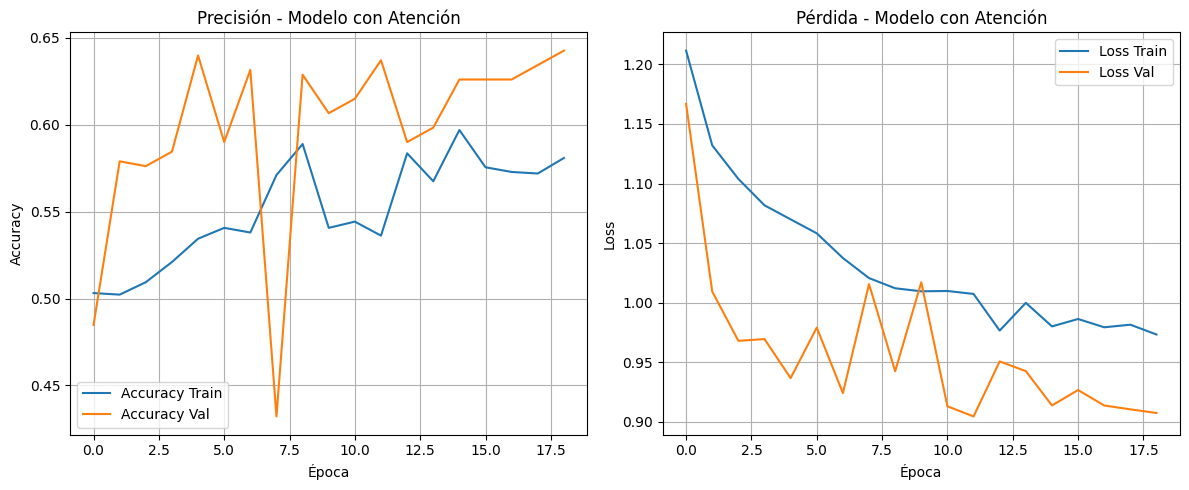


--- Evaluando el Modelo con Atención en el Set de Prueba ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step

Reporte de Clasificación:
              precision    recall  f1-score   support

      Alegre       0.61      0.76      0.68       113
      Neutra       0.44      0.40      0.42       105
      Triste       0.82      0.71      0.76       143

    accuracy                           0.64       361
   macro avg       0.62      0.62      0.62       361
weighted avg       0.64      0.64      0.64       361



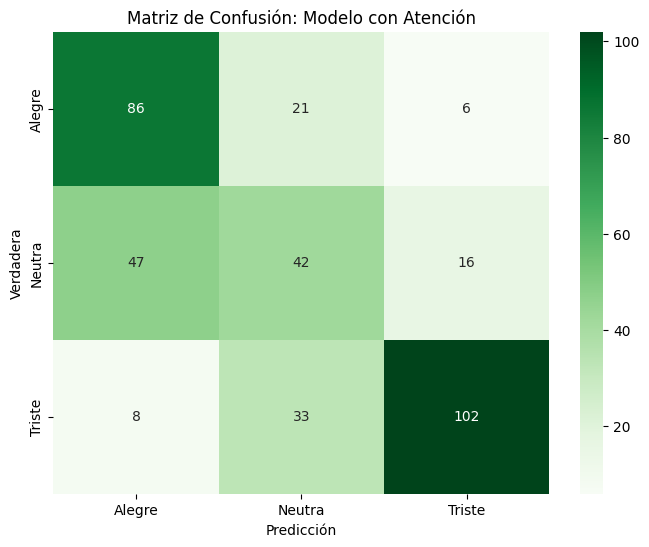

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Gráficos de Entrenamiento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_att.history['accuracy'], label='Accuracy Train')
plt.plot(history_att.history['val_accuracy'], label='Accuracy Val')
plt.title('Precisión - Modelo con Atención')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_att.history['loss'], label='Loss Train')
plt.plot(history_att.history['val_loss'], label='Loss Val')
plt.title('Pérdida - Modelo con Atención')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Evaluación y Matriz de Confusión
print("\n--- Evaluando el Modelo con Atención en el Set de Prueba ---")
y_pred_att_probs = model_attention.predict(X_test_cnn)
# Convertir probabilidades a etiquetas discretas para el reporte
y_pred_att_discrete = np.argmax(y_pred_att_probs, axis=1)
y_test_true_discrete = np.argmax(y_test_soft, axis=1)

print("\nReporte de Clasificación:")
print(classification_report(y_test_true_discrete, y_pred_att_discrete, target_names=le.classes_))

# Matriz de Confusión
cm_att = confusion_matrix(y_test_true_discrete, y_pred_att_discrete)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_att, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión: Modelo con Atención')
plt.xlabel('Predicción')
plt.ylabel('Verdadera')
plt.show()


## Paso 7: Probar el Modelo con un Archivo de Audio Propio

Utiliza esta celda para subir cualquier archivo `.wav` o `.mp3` y el modelo intentará predecir la emoción de la canción. Utilizaremos el modelo con Mecanismo de Atención (`model_attention`) ya que fue nuestro clasificador más robusto.

In [ ]:
import opensmile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import tkinter as tk
from tkinter import filedialog
warnings.filterwarnings('ignore')

# Validación de seguridad
if 'model_attention' not in locals() or 'le' not in locals():
    raise NameError("El modelo (model_attention) o el LabelEncoder (le) no están cargados en memoria. Asegúrate de ejecutar el entrenamiento antes.")

print("🎵 Selecciona un archivo de audio (.wav o .mp3):")
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)
file_name = filedialog.askopenfilename(title="Selecciona un archivo de audio", filetypes=[("Audio", "*.wav *.mp3")])
root.destroy()

if file_name:
    print(f"\nProcesando el archivo: {file_name}...")

    # 1. Configurar OpenSmile para extraer características comparables
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.ComParE_2016,
        feature_level=opensmile.FeatureLevel.LowLevelDescriptors,
    )

    try:
        # 2. Extracción de características
        print("Extrayendo características acústicas (esto puede tardar unos segundos)...")
        features = smile.process_file(file_name)

        # Convertir a array numérico
        seq = features.select_dtypes(include=[np.number]).values
        print(f"Frames extraídos: {seq.shape[0]} (características por frame: {seq.shape[1]})")

        # Ajustar si las dimensiones no coinciden exactamente (DEAM usaba 260, ComParE_2016 puede dar 130 o 260)
        if seq.shape[1] < num_features_per_frame:
            # Rellenar con ceros si faltan características
            pad_feat = num_features_per_frame - seq.shape[1]
            seq = np.pad(seq, ((0, 0), (0, pad_feat)), mode='constant')
        elif seq.shape[1] > num_features_per_frame:
            # Truncar si hay más
            seq = seq[:, :num_features_per_frame]

        # 3. Ajuste de longitud (Padding / Truncating) a max_seq_len
        target_len = max_seq_len
        if seq.shape[0] < target_len:
            pad_width = target_len - seq.shape[0]
            seq_padded = np.pad(seq, ((0, pad_width), (0, 0)), mode='constant')
            print(f"Aplicado padding de {pad_width} frames para alcanzar la longitud esperada.")
        else:
            seq_padded = seq[:target_len, :]
            print(f"Audio truncado a los primeros {target_len} frames.")

        # 4. Formatear para Keras (añadir dimensión del batch)
        X_infer = np.expand_dims(seq_padded, axis=0)

        # 5. Predicción
        print("\n🔮 Calculando la emoción...")
        pred_probs = model_attention.predict(X_infer, verbose=0)[0]

        # 6. Mostrar Resultados
        print("\n--- Resultados de la Predicción ---")
        for i, clase in enumerate(le.classes_):
            print(f"{clase}: {pred_probs[i]*100:.2f}%")

        clase_predominante = le.classes_[np.argmax(pred_probs)]
        print(f"\n>>> La emoción predominante es: **{clase_predominante.upper()}** <<<")

        # 7. Visualización Gráfica
        plt.figure(figsize=(8, 4))
        sns.barplot(x=pred_probs, y=le.classes_, palette='viridis')
        plt.title(f'Distribución de Probabilidades: {file_name}')
        plt.xlabel('Probabilidad')
        plt.xlim(0, 1)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\n❌ Error al procesar el audio: {e}")
else:
    print("\nNo se seleccionó ningún archivo. Vuelve a ejecutar la celda cuando estés listo.")

## Paso 8: Guardar y Descargar el Modelo

Vamos a guardar el modelo en formato `.keras` (el estándar actual de Keras/TensorFlow) y el `LabelEncoder` usando la librería estándar `pickle`. Una vez guardados, forzaremos su descarga.

In [17]:
import pickle
import os

# 1. Guardar el modelo de Keras
model_filename = 'modelo_emocion_atencion.keras'
model_attention.save(model_filename)
print(f"Modelo guardado con éxito como: {os.path.abspath(model_filename)}")

# 2. Guardar el LabelEncoder
le_filename = 'label_encoder.pkl'
with open(le_filename, 'wb') as f:
    pickle.dump(le, f)
print(f"LabelEncoder guardado con éxito como: {os.path.abspath(le_filename)}")

Modelo guardado con éxito como: /content/drive/MyDrive/Colab Notebooks/[Data]/[Trained Models]/musicAnalyzer(CNN)/modelo_emocion_atencion.keras
LabelEncoder guardado con éxito como: /content/drive/MyDrive/Colab Notebooks/[Data]/[Trained Models]/musicAnalyzer(CNN)/label_encoder.pkl
